# Kanji Learning Analysis with ResourceHub

This notebook demonstrates how KanKyouKen's ResourceHub can power kanji-specific
learning research. We load all three Tier 1 resources, explore their structure,
generate realistic synthetic practice events, and analyze performance patterns
across kanji properties, radical components, and JLPT levels.

**No Supabase connection required** -- this notebook runs entirely on ResourceHub
data and locally generated synthetic events.

Resources used:
- **kanjidic2_core**: 13,108 characters with stroke counts, grades, meanings, readings
- **kradfile_u**: 6,355 kanji decompositions into 253 radicals
- **jlpt_mappings**: 2,211 kanji mapped to JLPT N5--N1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from datetime import datetime, timedelta
from itertools import combinations

from kankyouken import ResourceHub

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({
    "figure.figsize": (13, 5),
    "figure.dpi": 120,
    "font.size": 11,
})

np.random.seed(42)
print("Setup complete")

Setup complete


In [2]:
hub = ResourceHub()

# Show what's available
print("Available resources:\n")
for r in hub.list_resources():
    print(f"  {r.id:<20s}  tier={r.tier}  type={r.type:<12s}  {r.title}")
    print(f"  {'':20s}  {r.description[:80]}...")
    print()

# Load all Tier 1 resources
kanjidic = hub.load("kanjidic2_core")
kradfile = hub.load("kradfile_u")
jlpt = hub.load("jlpt_mappings")

print(f"kanjidic2_core: {kanjidic['metadata']['character_count']:,} characters")
print(f"kradfile_u:     {kradfile['metadata']['character_count']:,} decompositions, {kradfile['metadata']['radical_count']} radicals")
print(f"jlpt_mappings:  {jlpt['metadata']['character_count']:,} kanji across N5-N1")

# Build unified kanji reference table
# kanjidic2_core uses old 4-level JLPT numbering; jlpt_mappings is the
# authoritative 5-level (N5-N1) source, so we use kanji_to_level from there.
radical_map = kradfile["radicals"]
catalog = kradfile["radical_catalog"]

kanji_df = pd.DataFrame(kanjidic["characters"])
kanji_df["jlpt_level"] = kanji_df["literal"].map(jlpt["kanji_to_level"])
kanji_df["radical_count"] = kanji_df["literal"].map(
    lambda k: len(radical_map.get(k, []))
)
kanji_df["radicals"] = kanji_df["literal"].map(
    lambda k: frozenset(radical_map.get(k, []))
)
kanji_df["meaning_count"] = kanji_df["meanings"].apply(len)
kanji_df["reading_count"] = kanji_df.apply(
    lambda r: len(r["readings_on"]) + len(r["readings_kun"]), axis=1
)

print(f"\nUnified DataFrame: {len(kanji_df)} rows x {len(kanji_df.columns)} cols")
print(f"With JLPT level: {kanji_df['jlpt_level'].notna().sum()}")
print(f"With radicals:    {(kanji_df['radical_count'] > 0).sum()}")
kanji_df[["literal", "stroke_count", "grade", "jlpt_level", "radical_count",
          "meaning_count", "freq"]].head(10)

Available resources:

  kanjidic2_core        tier=1  type=dictionary    KANJIDIC2 Core Dictionary
                        Comprehensive kanji character database with readings, meanings, stroke counts, a...

  kradfile_u            tier=1  type=analytics     KRADFILE Radical Decomposition
                        Kanji radical decomposition database mapping 6,355 characters to their component...

  jlpt_mappings         tier=1  type=analytics     JLPT Level Mappings
                        Japanese Language Proficiency Test (JLPT) level mappings for 2,211 kanji across ...

kanjidic2_core: 13,108 characters
kradfile_u:     6,355 decompositions, 253 radicals
jlpt_mappings:  2,211 kanji across N5-N1

Unified DataFrame: 13108 rows x 15 cols
With JLPT level: 2211
With radicals:    6355


,literal,stroke_count,grade,jlpt_level,radical_count,meaning_count,freq
0,𠀋,4,NaN,NaN,0,0,NaN
1,𠂉,2,NaN,NaN,0,0,NaN
2,𠂢,6,NaN,NaN,0,1,NaN
3,𠂤,6,NaN,NaN,0,2,NaN
4,𠆢,2,NaN,NaN,0,0,NaN
5,𠈓,8,NaN,NaN,0,0,NaN
6,𠌫,13,NaN,NaN,0,0,NaN
7,𠍱,14,NaN,NaN,0,0,NaN
8,𠎁,14,NaN,NaN,0,0,NaN
9,𠏹,16,NaN,NaN,0,0,NaN


## Resource Exploration

Before generating practice data, let's explore the distributions and statistics
of the reference data itself.

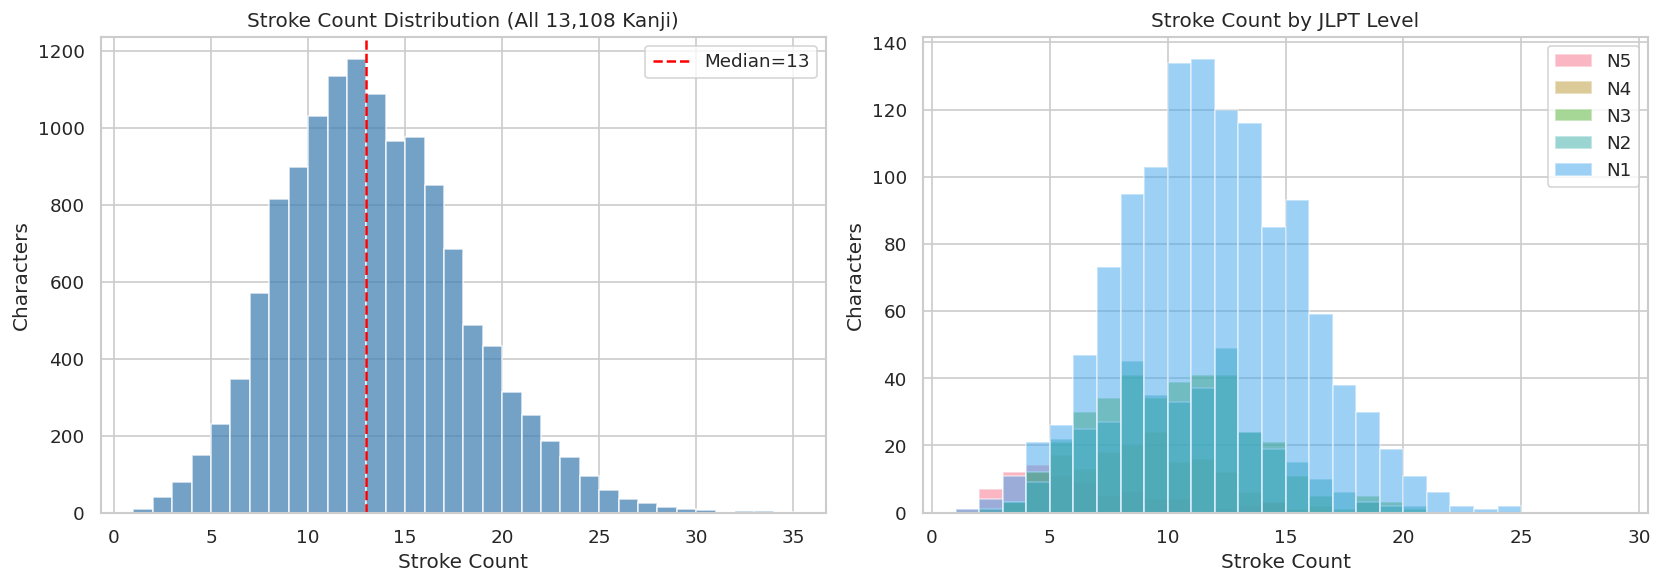

In [3]:
jlpt_order = ["N5", "N4", "N3", "N2", "N1"]
jlpt_kanji = kanji_df[kanji_df["jlpt_level"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All kanji
axes[0].hist(kanji_df["stroke_count"], bins=range(1, 36), color="steelblue",
             alpha=0.75, edgecolor="white")
axes[0].set_xlabel("Stroke Count")
axes[0].set_ylabel("Characters")
axes[0].set_title("Stroke Count Distribution (All 13,108 Kanji)")
axes[0].axvline(kanji_df["stroke_count"].median(), color="red", ls="--",
                label=f'Median={kanji_df["stroke_count"].median():.0f}')
axes[0].legend()

# By JLPT level
for level in jlpt_order:
    sub = jlpt_kanji[jlpt_kanji["jlpt_level"] == level]
    axes[1].hist(sub["stroke_count"], bins=range(1, 30), alpha=0.5, label=level)
axes[1].set_xlabel("Stroke Count")
axes[1].set_ylabel("Characters")
axes[1].set_title("Stroke Count by JLPT Level")
axes[1].legend()

plt.tight_layout()
plt.show()

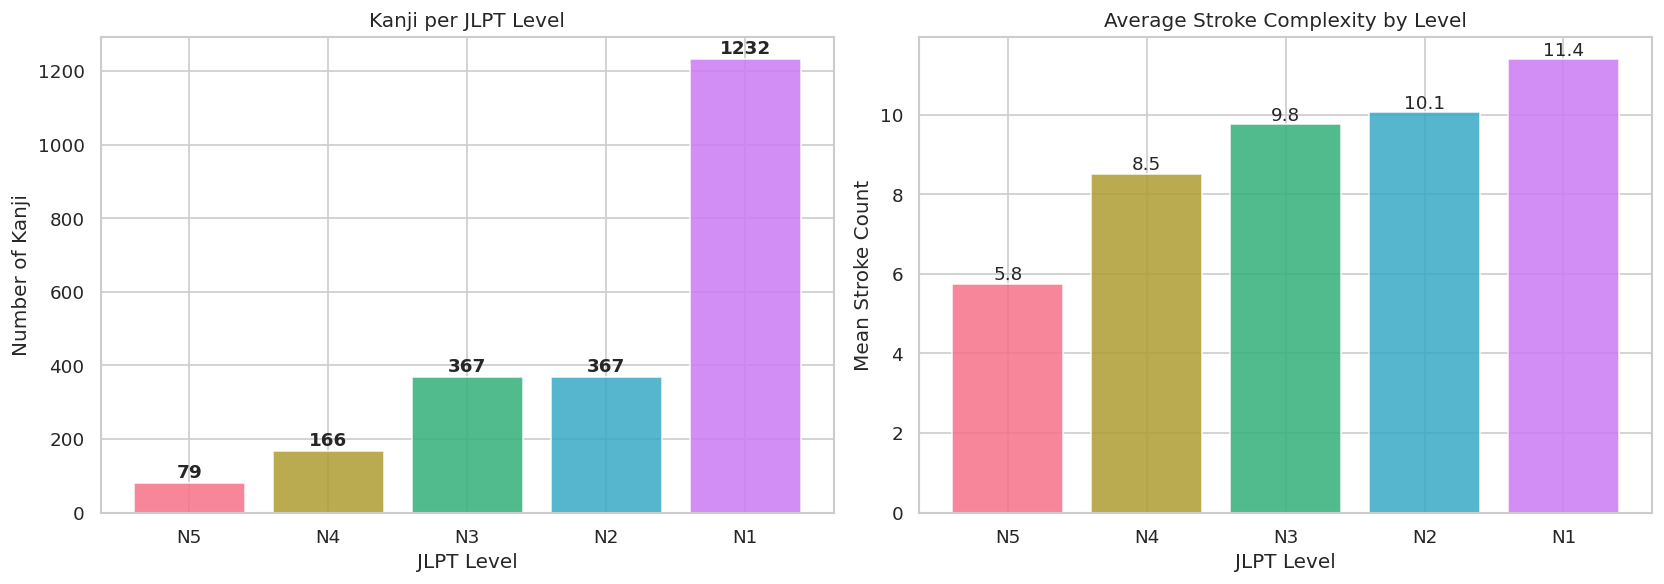

            count  mean_strokes  median_strokes  mean_radicals  mean_freq
jlpt_level                                                               
N5             79           5.8             5.0            2.2      193.3
N4            166           8.5             8.0            3.1      397.8
N3            367           9.8            10.0            3.7      550.5
N2            367          10.1            10.0            3.7      941.1
N1           1232          11.4            11.0            4.0     1478.3


In [4]:
jlpt_stats = (
    jlpt_kanji.groupby("jlpt_level")
    .agg(
        count=("literal", "count"),
        mean_strokes=("stroke_count", "mean"),
        median_strokes=("stroke_count", "median"),
        mean_radicals=("radical_count", "mean"),
        mean_freq=("freq", lambda x: x.dropna().mean()),
    )
    .reindex(jlpt_order)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("husl", 5)

axes[0].bar(jlpt_order, jlpt_stats["count"], color=colors, alpha=0.85,
            edgecolor="white")
for i, (level, row) in enumerate(jlpt_stats.iterrows()):
    axes[0].text(i, row["count"] + 15, str(int(row["count"])),
                 ha="center", fontweight="bold")
axes[0].set_xlabel("JLPT Level")
axes[0].set_ylabel("Number of Kanji")
axes[0].set_title("Kanji per JLPT Level")

axes[1].bar(jlpt_order, jlpt_stats["mean_strokes"], color=colors, alpha=0.85,
            edgecolor="white")
for i, (level, row) in enumerate(jlpt_stats.iterrows()):
    axes[1].text(i, row["mean_strokes"] + 0.1, f'{row["mean_strokes"]:.1f}',
                 ha="center")
axes[1].set_xlabel("JLPT Level")
axes[1].set_ylabel("Mean Stroke Count")
axes[1].set_title("Average Stroke Complexity by Level")

plt.tight_layout()
plt.show()
print(jlpt_stats.round(1).to_string())

/tmp/ipykernel_98790/3749296983.py:31: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98790/3749296983.py:31: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98790/3749296983.py:31: UserWarning: Glyph 65372 (\N{FULLWIDTH VERTICAL LINE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98790/3749296983.py:31: UserWarning: Glyph 12494 (\N{KATAKANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98790/3749296983.py:31: UserWarning: Glyph 26408 (\N{CJK UNIFIED IDEOGRAPH-6728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98790/3749296983.py:31: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_98790/3749296983.py:31: UserWarning: Glyph 12495 (\N{KATAKANA LETTER HA}) missing fr

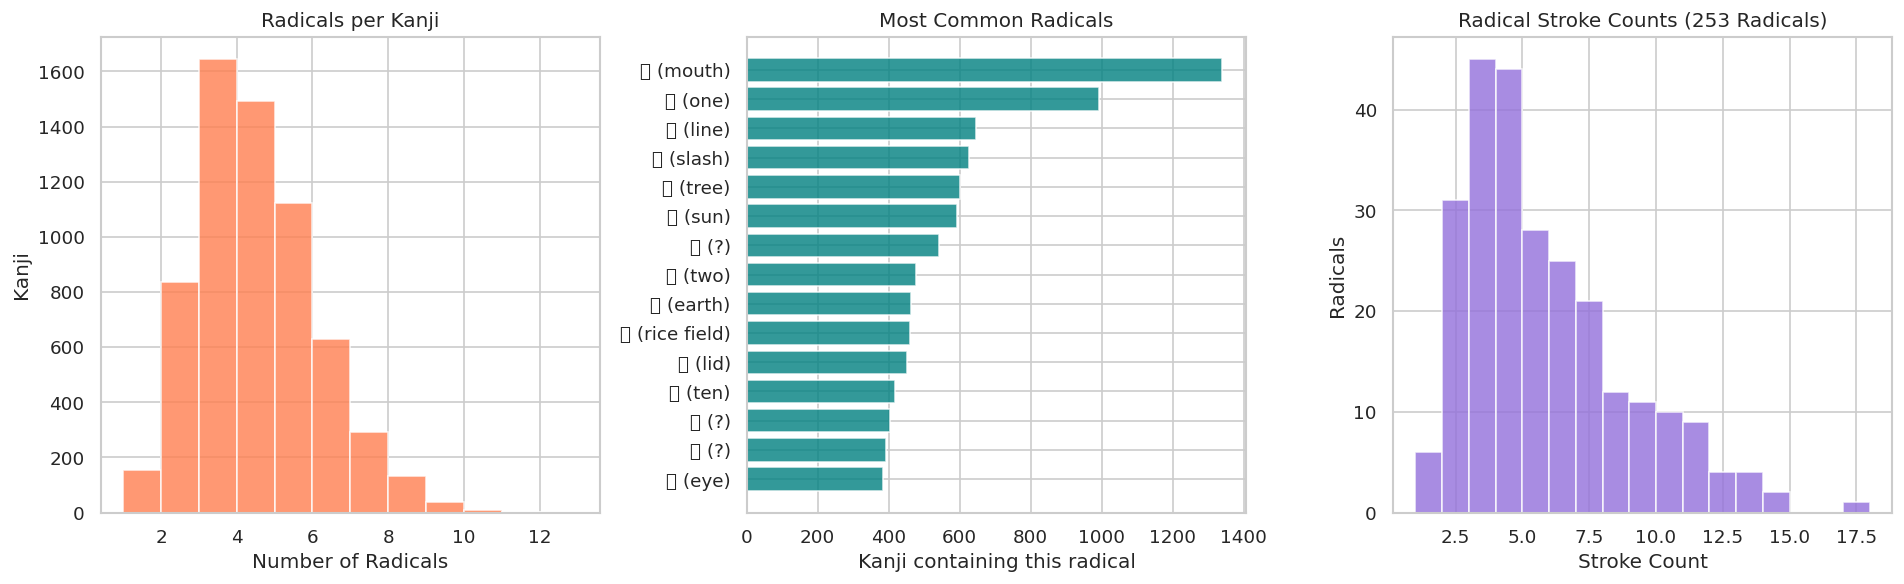

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Radicals per kanji
has_rad = kanji_df[kanji_df["radical_count"] > 0]
axes[0].hist(has_rad["radical_count"], bins=range(1, 14), color="coral",
             alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Number of Radicals")
axes[0].set_ylabel("Kanji")
axes[0].set_title("Radicals per Kanji")

# Top 15 most common radicals
kbr = kradfile["kanji_by_radical"]
top_radicals = sorted(kbr.items(), key=lambda x: len(x[1]), reverse=True)[:15]
rad_labels = [f'{r} ({catalog.get(r, {}).get("meaning", "?")})' for r, _ in top_radicals]
rad_counts = [len(k) for _, k in top_radicals]
axes[1].barh(range(len(rad_labels)), rad_counts, color="teal", alpha=0.8)
axes[1].set_yticks(range(len(rad_labels)))
axes[1].set_yticklabels(rad_labels)
axes[1].invert_yaxis()
axes[1].set_xlabel("Kanji containing this radical")
axes[1].set_title("Most Common Radicals")

# Radical stroke count distribution
rad_strokes = [info["stroke_count"] for info in catalog.values()]
axes[2].hist(rad_strokes, bins=range(1, 19), color="mediumpurple",
             alpha=0.8, edgecolor="white")
axes[2].set_xlabel("Stroke Count")
axes[2].set_ylabel("Radicals")
axes[2].set_title("Radical Stroke Counts (253 Radicals)")

plt.tight_layout()
plt.show()

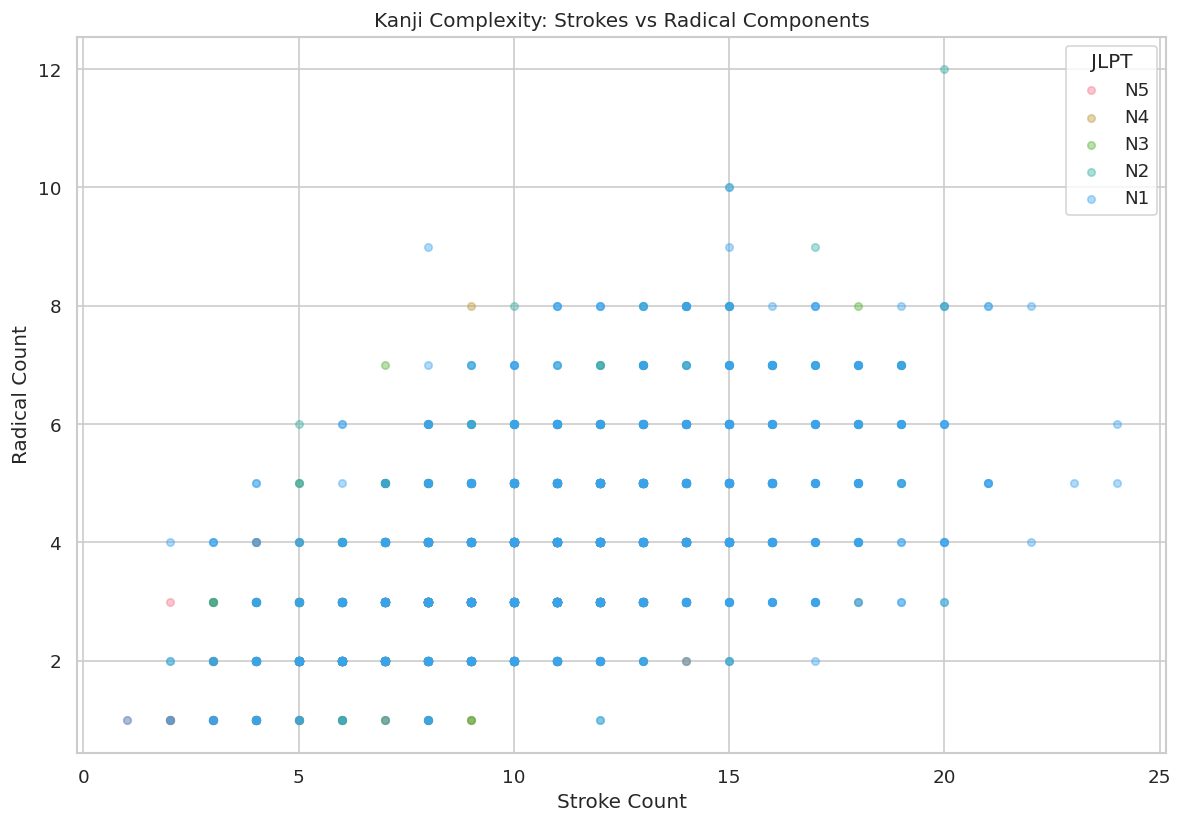

Pearson correlation (stroke_count vs radical_count): 0.586


In [6]:
plot_df = jlpt_kanji[jlpt_kanji["radical_count"] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 7))
for level in jlpt_order:
    sub = plot_df[plot_df["jlpt_level"] == level]
    ax.scatter(sub["stroke_count"], sub["radical_count"],
               alpha=0.4, s=20, label=level)
ax.set_xlabel("Stroke Count")
ax.set_ylabel("Radical Count")
ax.set_title("Kanji Complexity: Strokes vs Radical Components")
ax.legend(title="JLPT")
plt.tight_layout()
plt.show()

corr = plot_df[["stroke_count", "radical_count"]].corr().iloc[0, 1]
print(f"Pearson correlation (stroke_count vs radical_count): {corr:.3f}")

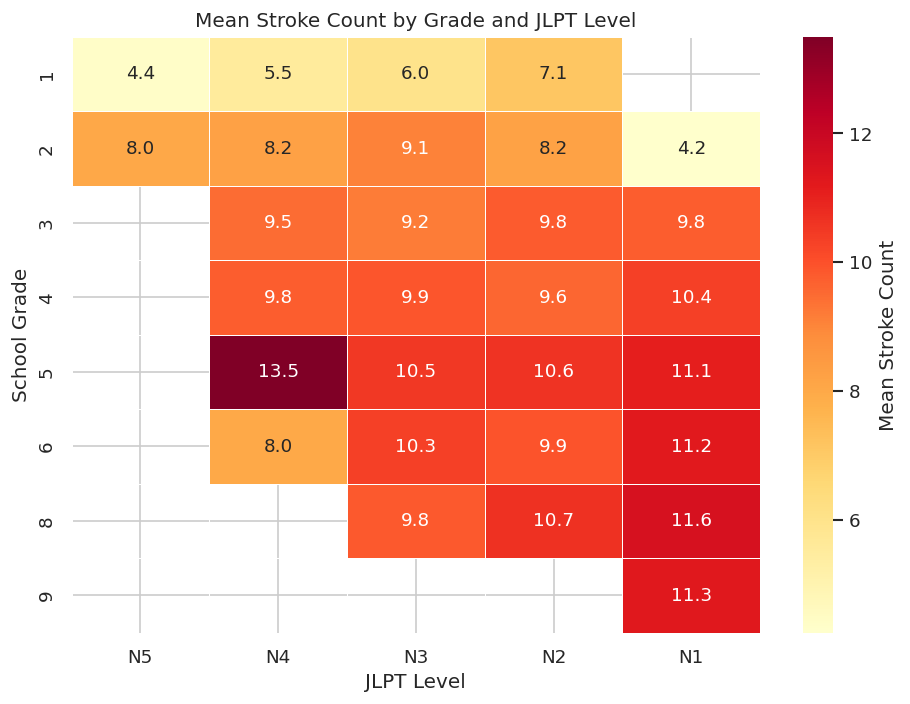

In [7]:
both = kanji_df[(kanji_df["grade"].notna()) & (kanji_df["jlpt_level"].notna())].copy()
both["grade"] = both["grade"].astype(int)

pivot = both.pivot_table(
    values="stroke_count", index="grade", columns="jlpt_level",
    aggfunc="mean"
).reindex(columns=jlpt_order)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Mean Stroke Count"}, ax=ax)
ax.set_xlabel("JLPT Level")
ax.set_ylabel("School Grade")
ax.set_title("Mean Stroke Count by Grade and JLPT Level")
plt.tight_layout()
plt.show()

## Synthetic Practice Event Generation

We generate realistic spaced-repetition practice data for 5 participants
studying JLPT N5--N3 kanji. The model includes:
- **Difficulty**: harder kanji (more strokes, higher JLPT level) = lower base accuracy
- **Response time**: correlates with stroke count (more strokes = slower recognition)
- **Learning**: accuracy improves over sessions (logistic growth)
- **Radical transfer**: kanji sharing radicals with previously-practiced kanji get a familiarity bonus
- **Individual differences**: participants have different skill levels and learning rates

In [8]:
# Practice pool: N5-N3 kanji with radical decompositions
practice_levels = ["N5", "N4", "N3"]
pool = kanji_df[
    (kanji_df["jlpt_level"].isin(practice_levels)) &
    (kanji_df["radical_count"] > 0)
].copy()

# Difficulty score (0-1): weighted combination of stroke count, radical count, JLPT rank
jlpt_rank = {"N5": 1, "N4": 2, "N3": 3, "N2": 4, "N1": 5}
pool["jlpt_rank"] = pool["jlpt_level"].map(jlpt_rank)

for col in ["stroke_count", "radical_count", "jlpt_rank"]:
    mn, mx = pool[col].min(), pool[col].max()
    pool[f"{col}_norm"] = (pool[col] - mn) / (mx - mn) if mx > mn else 0.0

pool["difficulty"] = (
    0.45 * pool["stroke_count_norm"] +
    0.25 * pool["radical_count_norm"] +
    0.30 * pool["jlpt_rank_norm"]
)

print(f"Practice pool: {len(pool)} kanji across {practice_levels}")
print(f"Difficulty range: {pool['difficulty'].min():.3f} -- {pool['difficulty'].max():.3f}")
print(f"Mean difficulty:  {pool['difficulty'].mean():.3f}")
print()
pool[["literal", "stroke_count", "radical_count", "jlpt_level", "difficulty"]].sort_values(
    "difficulty", ascending=False
).head(10)

Practice pool: 612 kanji across ['N5', 'N4', 'N3']
Difficulty range: 0.000 -- 1.000
Mean difficulty:  0.493



,literal,stroke_count,radical_count,jlpt_level,difficulty
10262,議,20,8,N3,1.000000
12058,顔,18,8,N3,0.952632
10256,警,19,7,N3,0.940602
12062,願,19,7,N3,0.940602
1030,優,17,7,N3,0.893233
5135,横,15,8,N3,0.881579
8785,舞,15,8,N3,0.881579
12066,類,18,6,N3,0.881203
11817,難,18,6,N3,0.881203
7570,積,16,7,N3,0.869549


In [9]:
participants = pd.DataFrame({
    "participant_id": [f"P{i:02d}" for i in range(1, 6)],
    "label":          ["Beginner", "Intermediate", "Advanced", "Steady", "Fast Learner"],
    "base_accuracy":  [0.35, 0.55, 0.75, 0.50, 0.40],
    "learning_rate":  [0.10, 0.08, 0.05, 0.06, 0.15],
    "rt_base_ms":     [2200, 1800, 1200, 1900, 2000],
})
print(participants.to_string(index=False))

participant_id        label  base_accuracy  learning_rate  rt_base_ms
           P01     Beginner           0.35           0.10        2200
           P02 Intermediate           0.55           0.08        1800
           P03     Advanced           0.75           0.05        1200
           P04       Steady           0.50           0.06        1900
           P05 Fast Learner           0.40           0.15        2000


In [10]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

pool_radicals = pool.set_index("literal")["radicals"].to_dict()
pool_difficulty = pool.set_index("literal")["difficulty"].to_dict()
pool_strokes = pool.set_index("literal")["stroke_count"].to_dict()
pool_kanji = pool["literal"].tolist()

events = []
base_date = datetime(2026, 1, 10, 9, 0, 0)

for _, p in participants.iterrows():
    seen_radicals = Counter()

    for session in range(10):
        session_date = base_date + timedelta(days=session * 3 + np.random.randint(0, 2))
        n_items = np.random.randint(35, 46)
        items = np.random.choice(pool_kanji, size=n_items, replace=False)

        for i, kanji in enumerate(items):
            difficulty = pool_difficulty[kanji]
            strokes = pool_strokes[kanji]
            rads = pool_radicals[kanji]

            # Radical transfer: fraction of radicals already seen 3+ times
            if rads:
                familiar_frac = sum(1 for r in rads if seen_radicals[r] > 2) / len(rads)
            else:
                familiar_frac = 0.0

            learning_bonus = p["learning_rate"] * session

            # Accuracy: logistic model
            logit = (
                (p["base_accuracy"] - 0.5) * 4
                - difficulty * 3.0
                + learning_bonus * 2.5
                + familiar_frac * 1.2
                + np.random.normal(0, 0.5)
            )
            correct = np.random.random() < sigmoid(logit)

            # Response time: base + stroke penalty + difficulty + noise
            rt_ms = int(max(300, (
                p["rt_base_ms"]
                + strokes * 40
                + difficulty * 500
                - session * 30
                - familiar_frac * 150
                + np.random.normal(0, 200)
            )))

            ts = session_date + timedelta(seconds=i * 8 + np.random.randint(0, 5))

            events.append({
                "participant_id": p["participant_id"],
                "session": session,
                "ts": ts,
                "kanji": kanji,
                "correct": correct,
                "rt_ms": rt_ms,
            })

            for r in rads:
                seen_radicals[r] += 1

events_df = pd.DataFrame(events)
events_df["ts"] = pd.to_datetime(events_df["ts"])

print(f"Generated {len(events_df):,} practice events")
print(f"Participants: {events_df['participant_id'].nunique()}")
print(f"Sessions: {events_df['session'].nunique()}")
print(f"Unique kanji practiced: {events_df['kanji'].nunique()}")
print(f"Overall accuracy: {events_df['correct'].mean():.1%}")
print(f"Mean RT: {events_df['rt_ms'].mean():.0f} ms")
events_df.head()

Generated 1,994 practice events
Participants: 5
Sessions: 10
Unique kanji practiced: 596
Overall accuracy: 54.4%
Mean RT: 2192 ms


,participant_id,session,ts,kanji,correct,rt_ms
0,P01,0,2026-01-10 09:00:02,気,False,2510
1,P01,0,2026-01-10 09:00:12,父,False,2161
2,P01,0,2026-01-10 09:00:19,太,True,2505
3,P01,0,2026-01-10 09:00:26,鳥,False,2958
4,P01,0,2026-01-10 09:00:32,和,False,2788


In [11]:
# Enrich events with kanji properties
kanji_props = pool[["literal", "stroke_count", "radical_count", "jlpt_level",
                     "jlpt_rank", "difficulty", "meanings"]].copy()
kanji_props = kanji_props.rename(columns={"literal": "kanji"})

df = events_df.merge(kanji_props, on="kanji", how="left")
df["correct_int"] = df["correct"].astype(int)

print(f"Enriched events: {len(df)} rows x {len(df.columns)} cols")
df[["participant_id", "session", "kanji", "correct", "rt_ms",
    "stroke_count", "jlpt_level", "difficulty"]].head(10)

Enriched events: 1994 rows x 13 cols


,participant_id,session,kanji,correct,rt_ms,stroke_count,jlpt_level,difficulty
0,P01,0,気,False,2510,6,N5,0.225564
1,P01,0,父,False,2161,4,N5,0.071053
2,P01,0,太,True,2505,4,N3,0.406767
3,P01,0,鳥,False,2958,11,N4,0.422556
4,P01,0,和,False,2788,8,N3,0.501504
5,P01,0,雑,False,2930,14,N3,0.679323
6,P01,0,木,True,2398,4,N5,0.071053
7,P01,0,万,True,2422,3,N5,0.118797
8,P01,0,歩,False,3085,8,N4,0.387218
9,P01,0,列,False,2862,6,N3,0.454135


## Performance by Kanji Properties

How do structural properties of kanji (stroke count, JLPT level,
radical complexity) predict accuracy and response time?

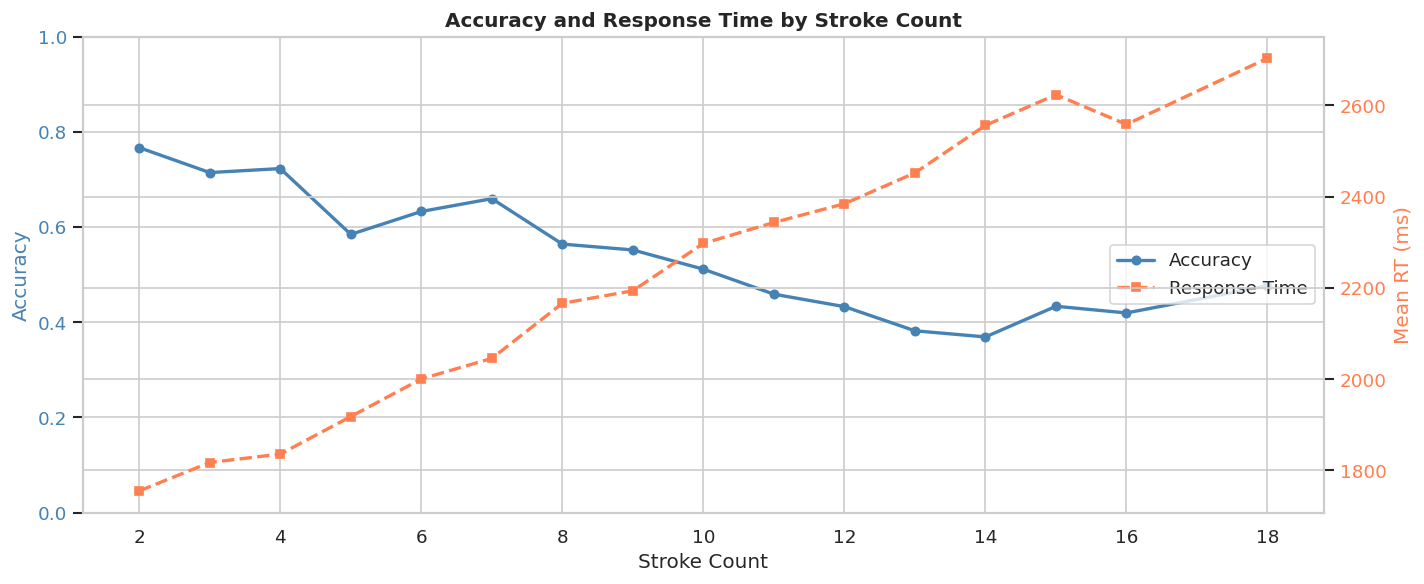

In [12]:
stroke_perf = (
    df.groupby("stroke_count")
    .agg(accuracy=("correct_int", "mean"), mean_rt=("rt_ms", "mean"),
         n=("correct_int", "count"))
    .reset_index()
)
stroke_perf = stroke_perf[stroke_perf["n"] >= 10]

fig, ax1 = plt.subplots(figsize=(12, 5))
color_acc, color_rt = "steelblue", "coral"

ax1.plot(stroke_perf["stroke_count"], stroke_perf["accuracy"],
         "o-", color=color_acc, lw=2, ms=5, label="Accuracy")
ax1.set_xlabel("Stroke Count")
ax1.set_ylabel("Accuracy", color=color_acc)
ax1.tick_params(axis="y", labelcolor=color_acc)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(stroke_perf["stroke_count"], stroke_perf["mean_rt"],
         "s--", color=color_rt, lw=2, ms=5, label="Response Time")
ax2.set_ylabel("Mean RT (ms)", color=color_rt)
ax2.tick_params(axis="y", labelcolor=color_rt)

ax1.set_title("Accuracy and Response Time by Stroke Count", fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()

/tmp/ipykernel_98790/189916077.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=session_acc, x="jlpt_level", y="correct_int",
/tmp/ipykernel_98790/189916077.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="jlpt_level", y="rt_ms",


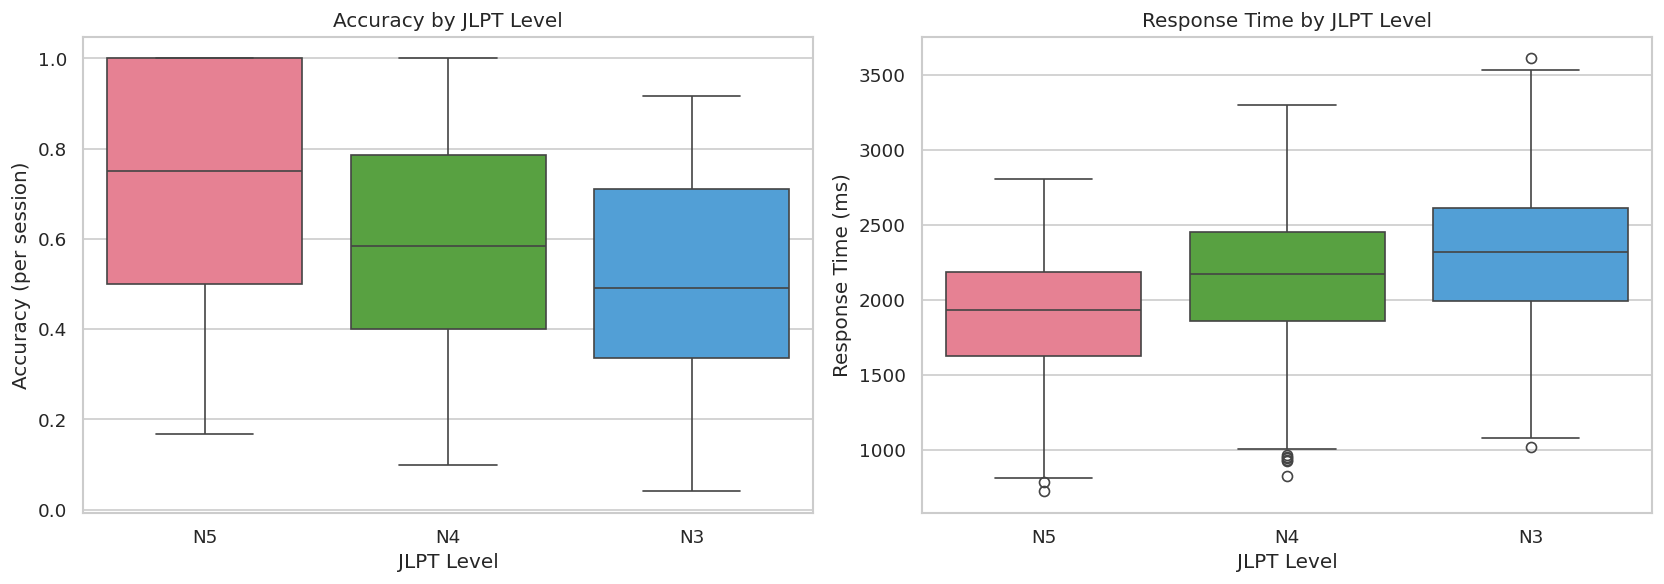

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

session_acc = (
    df.groupby(["participant_id", "session", "jlpt_level"])["correct_int"]
    .mean().reset_index()
)

sns.boxplot(data=session_acc, x="jlpt_level", y="correct_int",
            order=practice_levels, palette="husl", ax=axes[0])
axes[0].set_xlabel("JLPT Level")
axes[0].set_ylabel("Accuracy (per session)")
axes[0].set_title("Accuracy by JLPT Level")

sns.boxplot(data=df, x="jlpt_level", y="rt_ms",
            order=practice_levels, palette="husl", ax=axes[1])
axes[1].set_xlabel("JLPT Level")
axes[1].set_ylabel("Response Time (ms)")
axes[1].set_title("Response Time by JLPT Level")

plt.tight_layout()
plt.show()

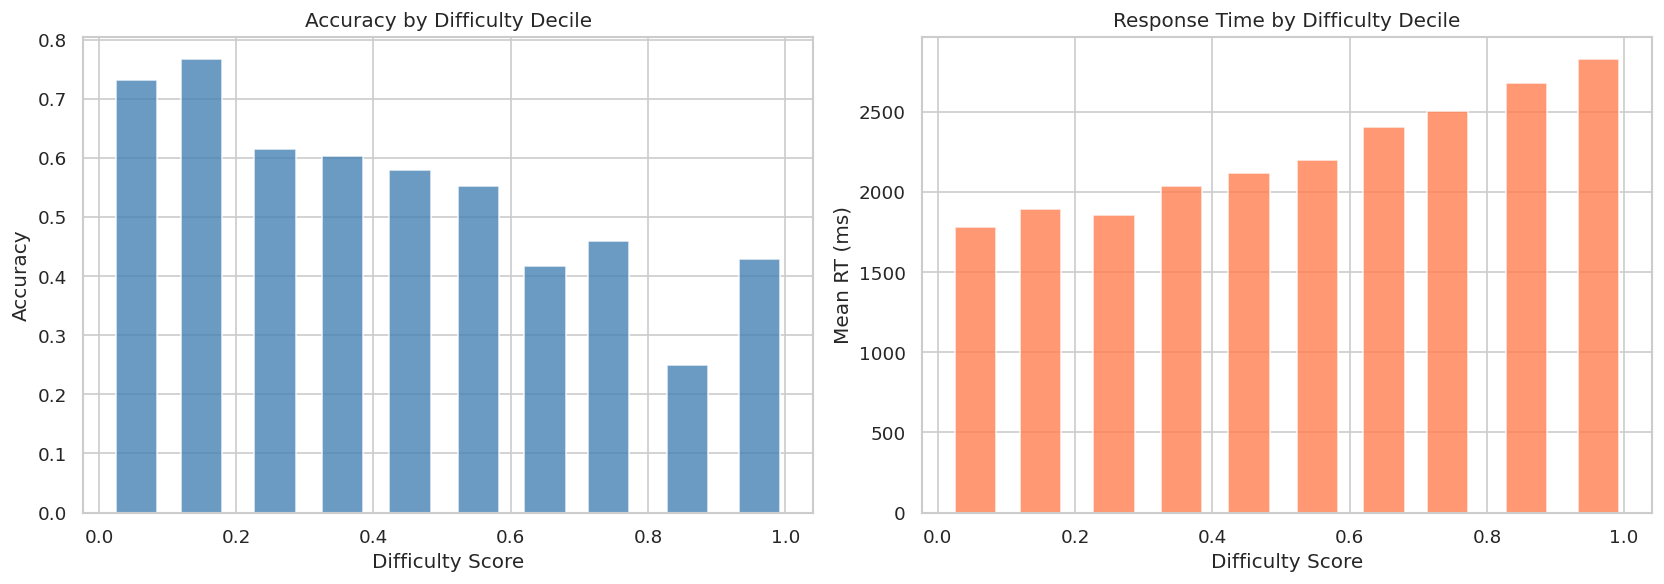

In [14]:
df["difficulty_bin"] = pd.cut(df["difficulty"], bins=10, labels=False)

diff_perf = (
    df.groupby("difficulty_bin")
    .agg(accuracy=("correct_int", "mean"), mean_rt=("rt_ms", "mean"),
         mean_diff=("difficulty", "mean"), n=("correct_int", "count"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(diff_perf["mean_diff"], diff_perf["accuracy"], width=0.06,
            color="steelblue", alpha=0.8, edgecolor="white")
axes[0].set_xlabel("Difficulty Score")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by Difficulty Decile")

axes[1].bar(diff_perf["mean_diff"], diff_perf["mean_rt"], width=0.06,
            color="coral", alpha=0.8, edgecolor="white")
axes[1].set_xlabel("Difficulty Score")
axes[1].set_ylabel("Mean RT (ms)")
axes[1].set_title("Response Time by Difficulty Decile")

plt.tight_layout()
plt.show()

## Radical Component Analysis

Radicals are the building blocks of kanji. This section explores whether
sharing radical components predicts performance transfer -- if you've
practiced kanji containing radical X, do you perform better on new kanji
that also contain X?

In [15]:
# Explode each event into its radical components
radical_rows = []
for _, row in df.iterrows():
    rads = radical_map.get(row["kanji"], [])
    for r in rads:
        radical_rows.append({
            "radical": r,
            "correct": row["correct_int"],
            "rt_ms": row["rt_ms"],
            "session": row["session"],
            "participant_id": row["participant_id"],
        })

radical_df = pd.DataFrame(radical_rows)

radical_perf = (
    radical_df.groupby("radical")
    .agg(accuracy=("correct", "mean"), mean_rt=("rt_ms", "mean"),
         n_events=("correct", "count"))
    .reset_index()
)
radical_perf["stroke_count"] = radical_perf["radical"].map(
    lambda r: catalog.get(r, {}).get("stroke_count", None)
)
radical_perf["meaning"] = radical_perf["radical"].map(
    lambda r: catalog.get(r, {}).get("meaning", "?")
)
radical_perf = radical_perf[radical_perf["n_events"] >= 20].sort_values("accuracy")

print(f"Radicals with >= 20 events: {len(radical_perf)}")
print("\nHardest radicals (lowest accuracy):")
print(radical_perf.head(10)[["radical", "meaning", "accuracy", "mean_rt", "n_events"]].to_string(index=False))
print("\nEasiest radicals (highest accuracy):")
print(radical_perf.tail(10)[["radical", "meaning", "accuracy", "mean_rt", "n_events"]].to_string(index=False))

Radicals with >= 20 events: 83

Hardest radicals (lowest accuracy):
radical      meaning  accuracy     mean_rt  n_events
      广 dotted cliff  0.346154 2142.076923        26
      巾        cloth  0.363636 2193.636364        22
      士      samurai  0.366667 2313.366667        30
      斤          axe  0.370370 2295.259259        27
      戈      halberd  0.371429 2446.342857        35
      刀        knife  0.380952 2294.380952        21
      ⺣            ?  0.400000 2468.233333        30
      冫          ice  0.406250 2358.031250        32
      ⺌            ?  0.406250 2176.437500        32
      羊        sheep  0.406250 2432.531250        32

Easiest radicals (highest accuracy):
radical    meaning  accuracy     mean_rt  n_events
      又      again  0.597701 2196.954023        87
      工      craft  0.600000 2083.100000        30
      卜 divination  0.607143 1944.535714        28
      勿          ?  0.620690 2429.206897        29
      耳        ear  0.625000 2217.791667        24
     

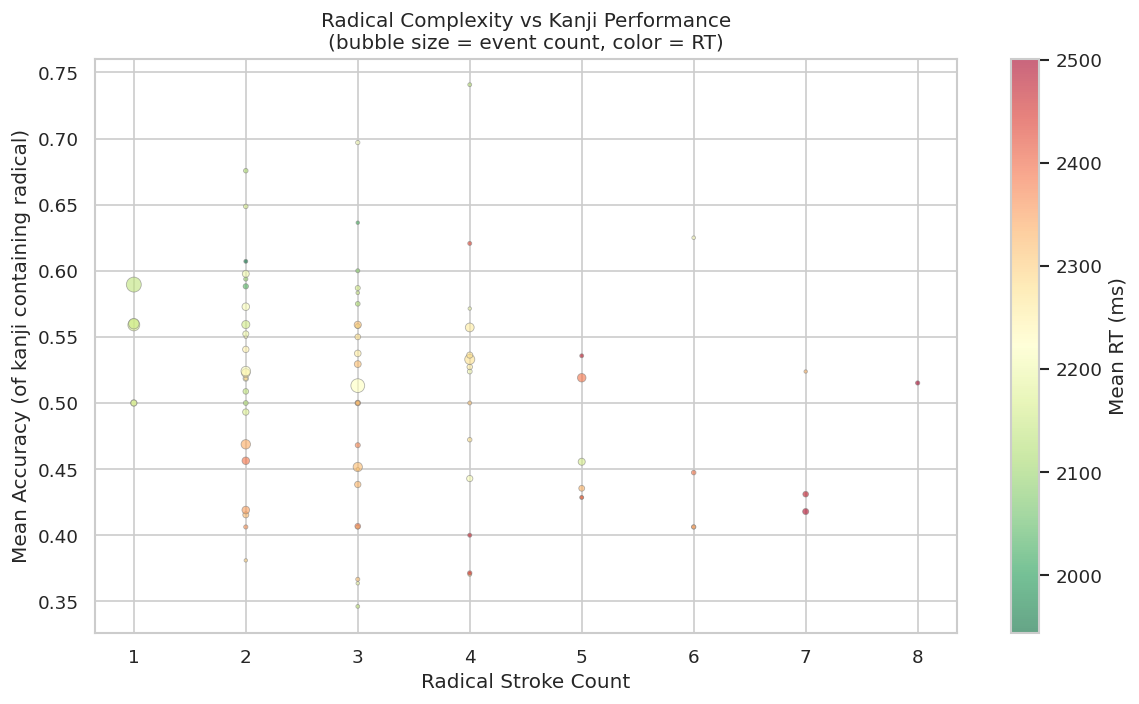

In [16]:
plot_rp = radical_perf[radical_perf["stroke_count"].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    plot_rp["stroke_count"], plot_rp["accuracy"],
    s=plot_rp["n_events"] / 5, alpha=0.6, c=plot_rp["mean_rt"],
    cmap="RdYlGn_r", edgecolors="gray", linewidth=0.5
)
plt.colorbar(scatter, ax=ax, label="Mean RT (ms)")
ax.set_xlabel("Radical Stroke Count")
ax.set_ylabel("Mean Accuracy (of kanji containing radical)")
ax.set_title("Radical Complexity vs Kanji Performance\n(bubble size = event count, color = RT)")

plt.tight_layout()
plt.show()

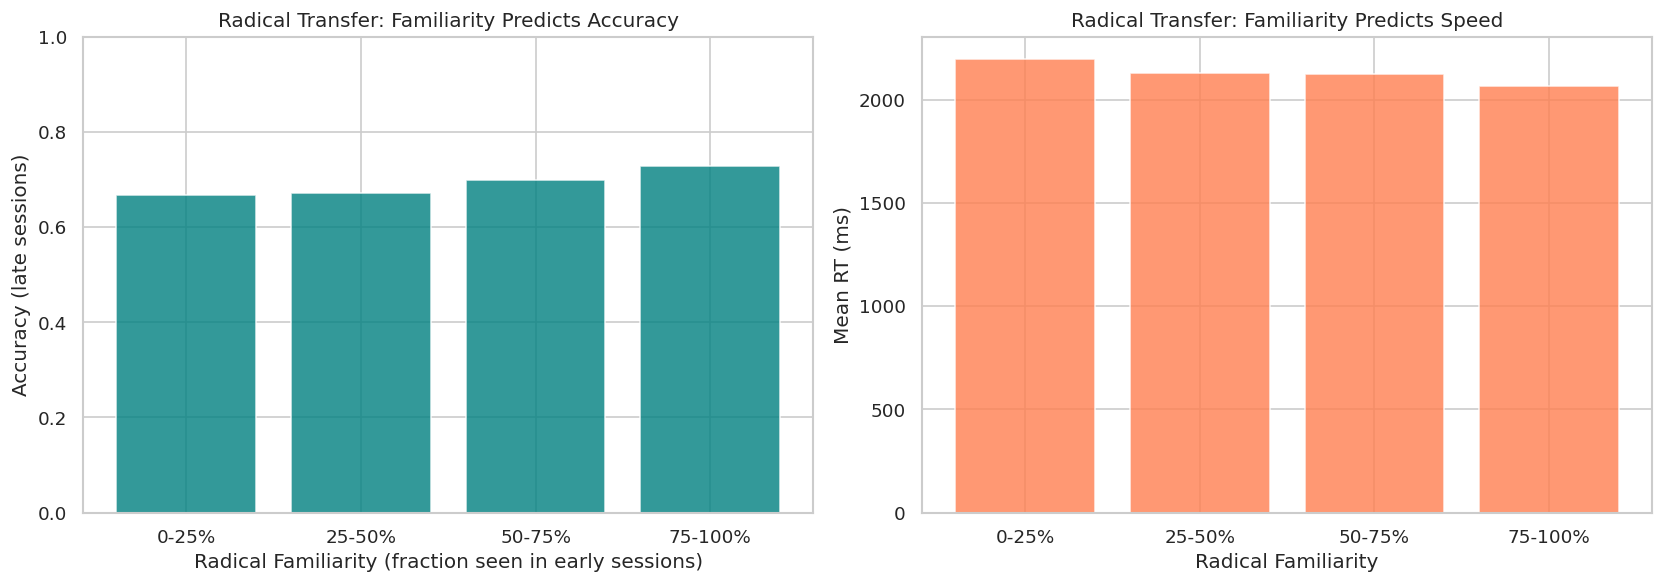

In [17]:
# Split early (0-4) and late (5-9) sessions
early = df[df["session"] < 5]
late = df[df["session"] >= 5]

transfer_rows = []
for pid in df["participant_id"].unique():
    early_p = early[early["participant_id"] == pid]
    seen_rad_counts = Counter()
    for kanji in early_p["kanji"]:
        for r in radical_map.get(kanji, []):
            seen_rad_counts[r] += 1

    late_p = late[late["participant_id"] == pid]
    for _, row in late_p.iterrows():
        rads = radical_map.get(row["kanji"], [])
        if not rads:
            continue
        familiar_frac = sum(1 for r in rads if seen_rad_counts[r] >= 3) / len(rads)
        transfer_rows.append({
            "participant_id": pid,
            "kanji": row["kanji"],
            "correct": row["correct_int"],
            "rt_ms": row["rt_ms"],
            "familiar_frac": familiar_frac,
        })

transfer_df = pd.DataFrame(transfer_rows)
transfer_df["familiarity_bin"] = pd.cut(
    transfer_df["familiar_frac"],
    bins=[0, 0.25, 0.50, 0.75, 1.01],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"]
)

fam_acc = transfer_df.groupby("familiarity_bin", observed=True)["correct"].mean()
fam_rt = transfer_df.groupby("familiarity_bin", observed=True)["rt_ms"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(fam_acc)), fam_acc.values, color="teal", alpha=0.8, edgecolor="white")
axes[0].set_xticks(range(len(fam_acc)))
axes[0].set_xticklabels(fam_acc.index)
axes[0].set_xlabel("Radical Familiarity (fraction seen in early sessions)")
axes[0].set_ylabel("Accuracy (late sessions)")
axes[0].set_title("Radical Transfer: Familiarity Predicts Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(range(len(fam_rt)), fam_rt.values, color="coral", alpha=0.8, edgecolor="white")
axes[1].set_xticks(range(len(fam_rt)))
axes[1].set_xticklabels(fam_rt.index)
axes[1].set_xlabel("Radical Familiarity")
axes[1].set_ylabel("Mean RT (ms)")
axes[1].set_title("Radical Transfer: Familiarity Predicts Speed")

plt.tight_layout()
plt.show()

In [18]:
# Radical pair co-occurrence analysis
practiced_kanji = set(df["kanji"].unique())
pair_counts = Counter()
for kanji in practiced_kanji:
    rads = sorted(radical_map.get(kanji, []))
    for pair in combinations(rads, 2):
        pair_counts[pair] += 1

top_pairs = pair_counts.most_common(15)

pair_data = []
for (r1, r2), count in top_pairs:
    m1 = catalog.get(r1, {}).get("meaning", "?")
    m2 = catalog.get(r2, {}).get("meaning", "?")
    both_kanji = [k for k in practiced_kanji
                  if r1 in radical_map.get(k, []) and r2 in radical_map.get(k, [])]
    sub = df[df["kanji"].isin(both_kanji)]
    if len(sub) >= 10:
        pair_data.append({
            "pair": f"{r1}({m1}) + {r2}({m2})",
            "kanji_count": count,
            "events": len(sub),
            "accuracy": sub["correct_int"].mean(),
            "mean_rt": sub["rt_ms"].mean(),
        })

pair_df = pd.DataFrame(pair_data)
print("Top Radical Pairs and Their Performance:")
print(pair_df.to_string(index=False))

Top Radical Pairs and Their Performance:
              pair  kanji_count  events  accuracy     mean_rt
  一(one) + ｜(line)           37     107  0.579439 2183.102804
 ノ(slash) + 一(one)           32     109  0.596330 2079.055046
     ハ(?) + 目(eye)           24      72  0.444444 2472.541667
 一(one) + 口(mouth)           24      83  0.518072 2140.048193
   ハ(?) + 貝(shell)           22      67  0.417910 2488.597015
 目(eye) + 貝(shell)           22      67  0.417910 2488.597015
ノ(slash) + ｜(line)           19      57  0.631579 2181.561404
   二(two) + 亠(lid)           16      45  0.466667 2353.622222
   一(one) + 二(two)           16      50  0.540000 2183.940000
     ハ(?) + 一(one)           15      46  0.413043 2256.804348
   一(one) + 日(sun)           14      59  0.593220 2226.457627
  日(sun) + ｜(line)           14      48  0.583333 2127.354167
  二(two) + ｜(line)           14      37  0.513514 2038.621622
  一(one) + 亅(hook)           14      47  0.595745 2120.978723
 木(tree) + ｜(line)           

## Learning Curves

How does performance improve over practice sessions? Do all participants
and all JLPT levels show the same learning trajectory?

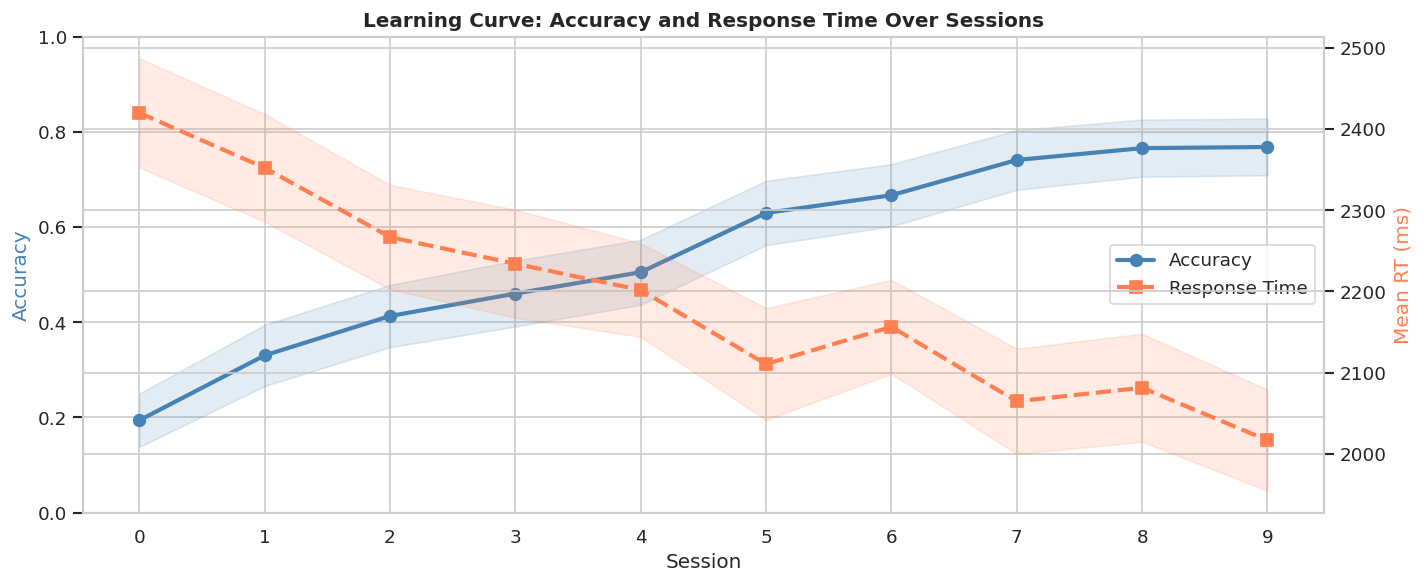

In [19]:
session_overall = (
    df.groupby("session")
    .agg(accuracy=("correct_int", "mean"), mean_rt=("rt_ms", "mean"),
         se_acc=("correct_int", "sem"), se_rt=("rt_ms", "sem"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(session_overall["session"], session_overall["accuracy"],
         "o-", color="steelblue", lw=2.5, ms=7, label="Accuracy")
ax1.fill_between(session_overall["session"],
                 session_overall["accuracy"] - 1.96 * session_overall["se_acc"],
                 session_overall["accuracy"] + 1.96 * session_overall["se_acc"],
                 color="steelblue", alpha=0.15)
ax1.set_xlabel("Session")
ax1.set_ylabel("Accuracy", color="steelblue")
ax1.set_ylim(0, 1)
ax1.set_xticks(range(10))

ax2 = ax1.twinx()
ax2.plot(session_overall["session"], session_overall["mean_rt"],
         "s--", color="coral", lw=2.5, ms=7, label="Response Time")
ax2.fill_between(session_overall["session"],
                 session_overall["mean_rt"] - 1.96 * session_overall["se_rt"],
                 session_overall["mean_rt"] + 1.96 * session_overall["se_rt"],
                 color="coral", alpha=0.15)
ax2.set_ylabel("Mean RT (ms)", color="coral")

ax1.set_title("Learning Curve: Accuracy and Response Time Over Sessions", fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.tight_layout()
plt.show()

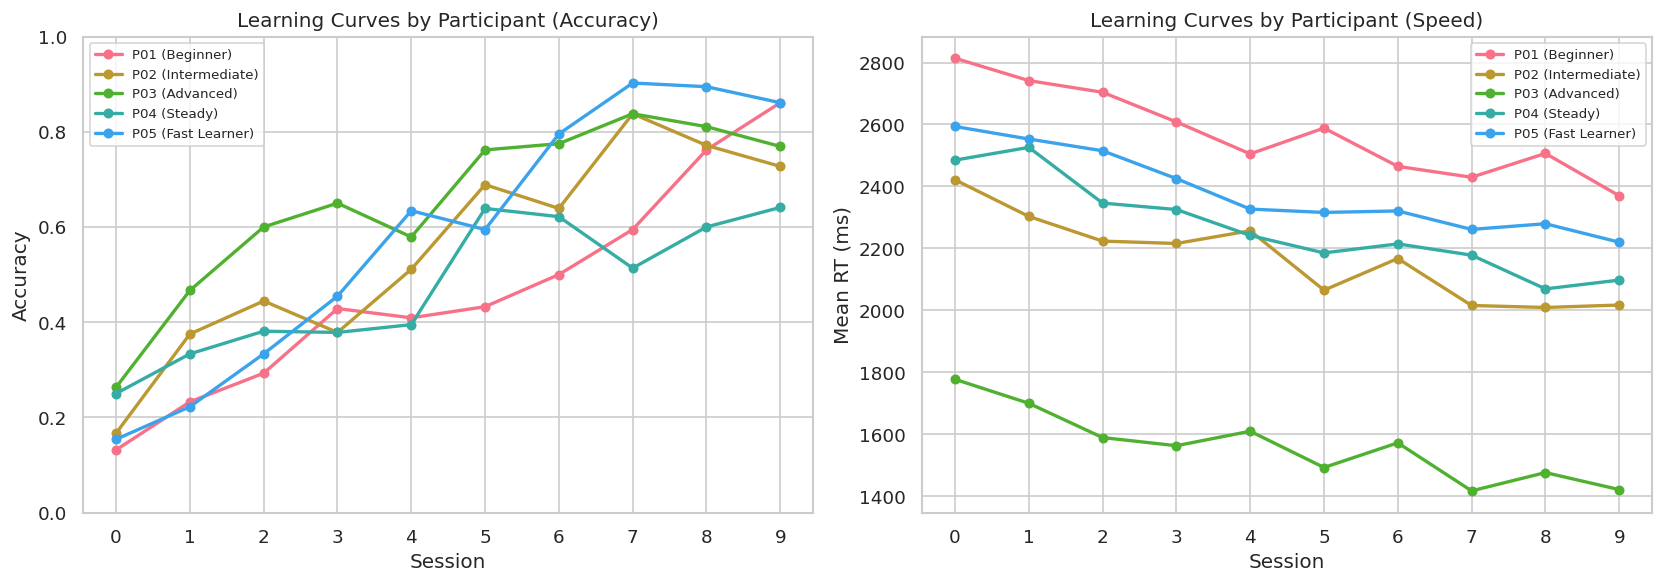

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for pid in sorted(df["participant_id"].unique()):
    p_label = participants.loc[participants["participant_id"] == pid, "label"].values[0]
    sub = df[df["participant_id"] == pid].groupby("session").agg(
        accuracy=("correct_int", "mean"), mean_rt=("rt_ms", "mean")
    ).reset_index()
    axes[0].plot(sub["session"], sub["accuracy"], "o-", lw=2, ms=5,
                 label=f"{pid} ({p_label})")
    axes[1].plot(sub["session"], sub["mean_rt"], "o-", lw=2, ms=5,
                 label=f"{pid} ({p_label})")

axes[0].set_xlabel("Session")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Learning Curves by Participant (Accuracy)")
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].set_xticks(range(10))

axes[1].set_xlabel("Session")
axes[1].set_ylabel("Mean RT (ms)")
axes[1].set_title("Learning Curves by Participant (Speed)")
axes[1].legend(fontsize=8)
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

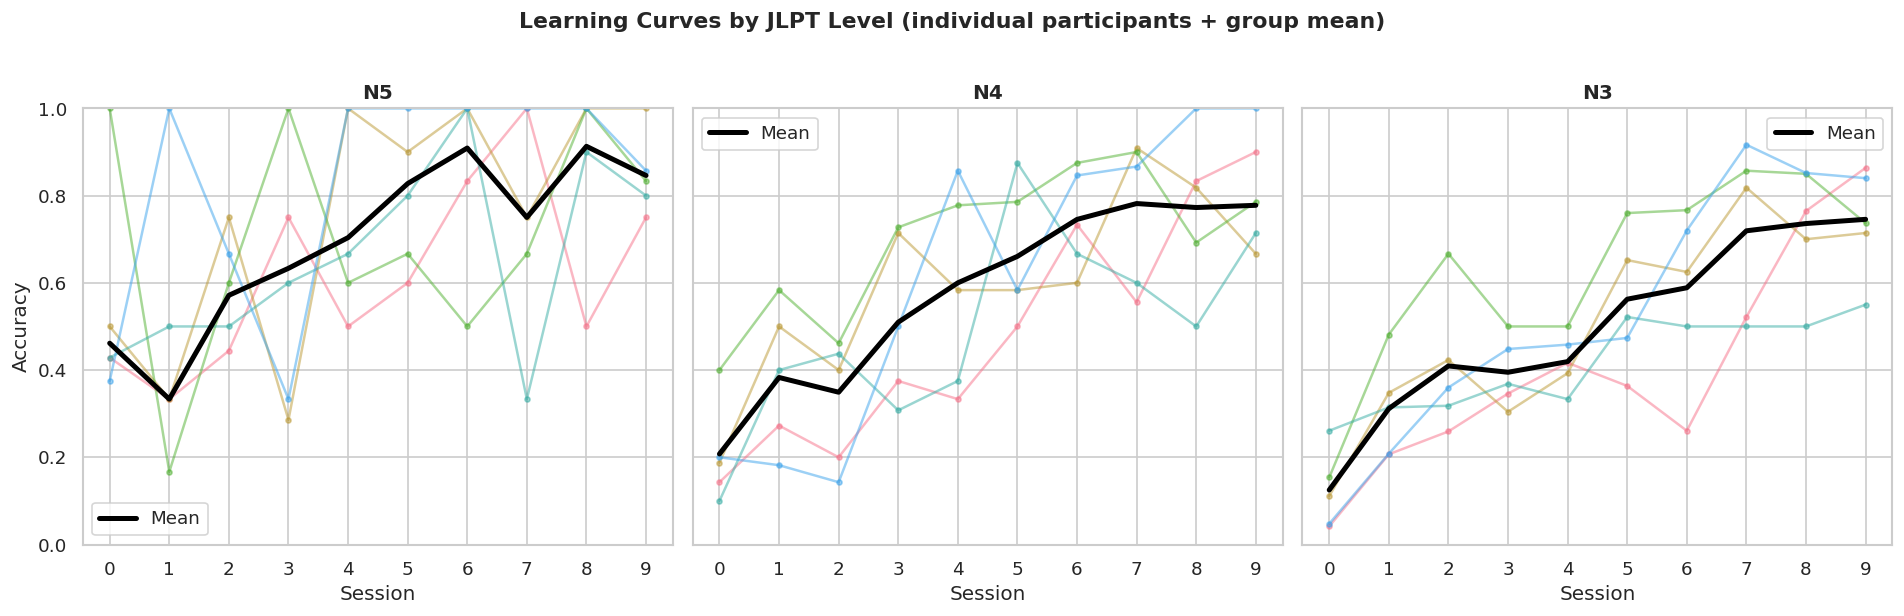

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for i, level in enumerate(practice_levels):
    sub = df[df["jlpt_level"] == level]
    for pid in sorted(df["participant_id"].unique()):
        psub = sub[sub["participant_id"] == pid].groupby("session")["correct_int"].mean().reset_index()
        axes[i].plot(psub["session"], psub["correct_int"], "o-", alpha=0.5, lw=1.5, ms=3)

    overall = sub.groupby("session")["correct_int"].mean().reset_index()
    axes[i].plot(overall["session"], overall["correct_int"], "k-", lw=3, ms=7,
                 label="Mean", zorder=10)
    axes[i].set_title(f"{level}", fontweight="bold")
    axes[i].set_xlabel("Session")
    axes[i].set_xticks(range(10))
    axes[i].set_ylim(0, 1)
    if i == 0:
        axes[i].set_ylabel("Accuracy")
    axes[i].legend()

plt.suptitle("Learning Curves by JLPT Level (individual participants + group mean)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Combined Multi-Factor Analysis

Multi-factor views joining all three resources with the event data.

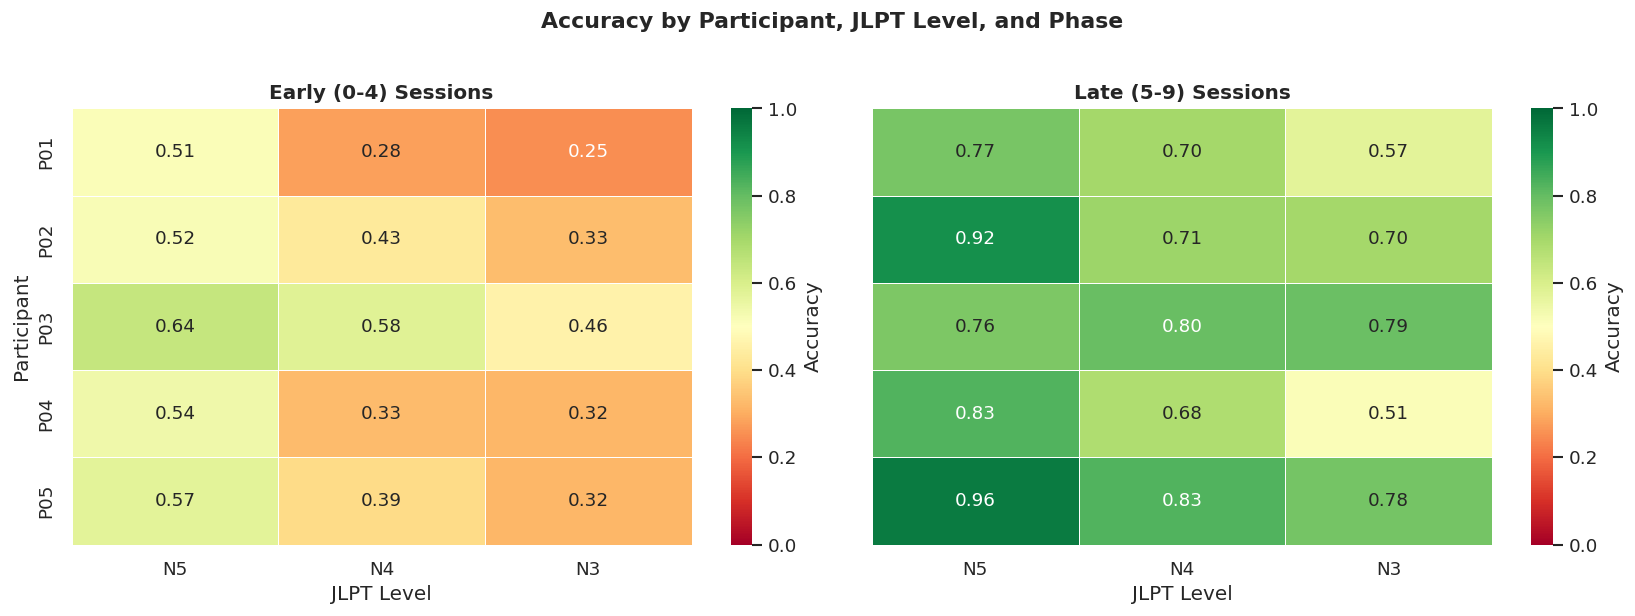

In [22]:
df["phase"] = df["session"].apply(lambda s: "Early (0-4)" if s < 5 else "Late (5-9)")

phase_acc = (
    df.groupby(["participant_id", "jlpt_level", "phase"])["correct_int"]
    .mean().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, phase in enumerate(["Early (0-4)", "Late (5-9)"]):
    pivot = phase_acc[phase_acc["phase"] == phase].pivot_table(
        index="participant_id", columns="jlpt_level", values="correct_int"
    ).reindex(columns=practice_levels)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Accuracy"}, ax=axes[i])
    axes[i].set_title(f"{phase} Sessions", fontweight="bold")
    axes[i].set_xlabel("JLPT Level")
    if i == 0:
        axes[i].set_ylabel("Participant")
    else:
        axes[i].set_ylabel("")

plt.suptitle("Accuracy by Participant, JLPT Level, and Phase", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

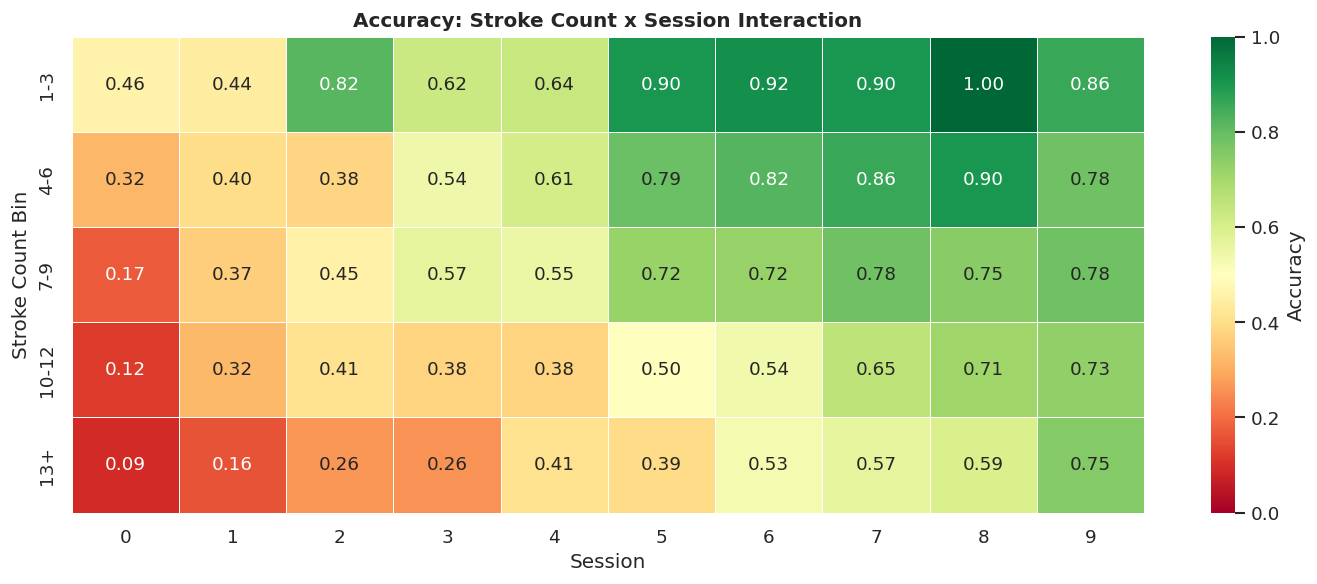

In [23]:
df["stroke_bin"] = pd.cut(df["stroke_count"], bins=[0, 3, 6, 9, 12, 20],
                          labels=["1-3", "4-6", "7-9", "10-12", "13+"])

heat = df.pivot_table(index="stroke_bin", columns="session",
                      values="correct_int", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Accuracy"}, ax=ax)
ax.set_xlabel("Session")
ax.set_ylabel("Stroke Count Bin")
ax.set_title("Accuracy: Stroke Count x Session Interaction", fontweight="bold")
plt.tight_layout()
plt.show()

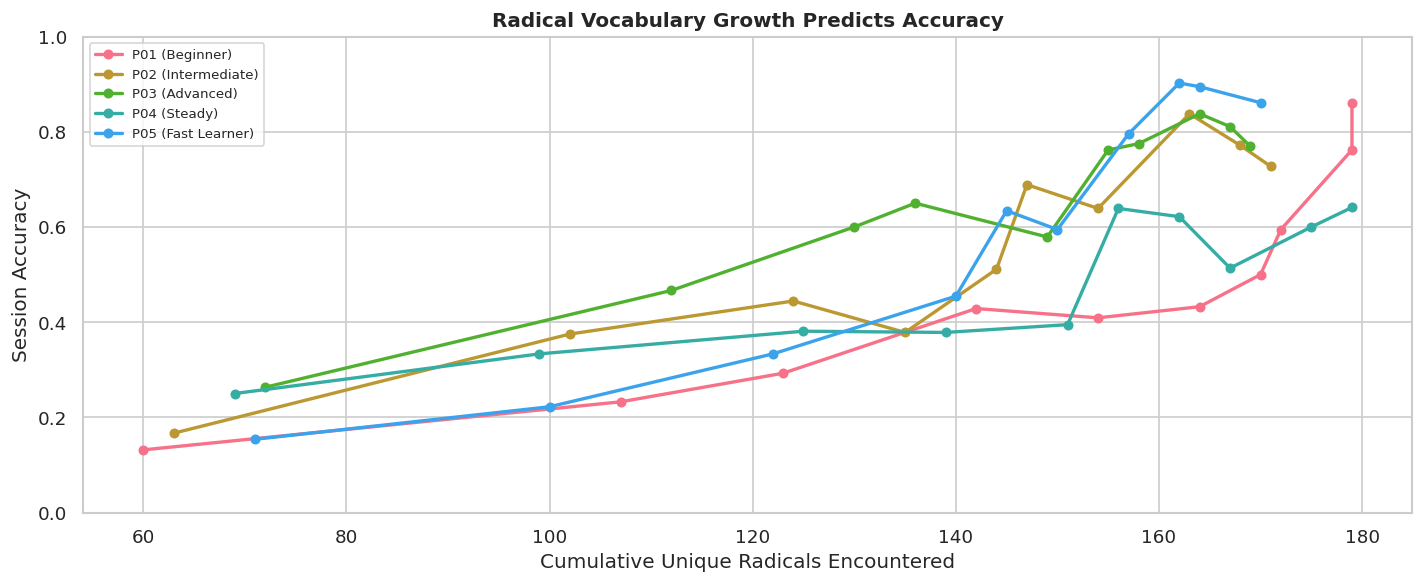

In [24]:
diversity_rows = []
for pid in sorted(df["participant_id"].unique()):
    p_data = df[df["participant_id"] == pid].sort_values("ts")
    unique_rads = set()
    for session in range(10):
        session_data = p_data[p_data["session"] == session]
        for kanji in session_data["kanji"]:
            unique_rads.update(radical_map.get(kanji, []))
        diversity_rows.append({
            "participant_id": pid,
            "session": session,
            "unique_radicals": len(unique_rads),
            "accuracy": session_data["correct_int"].mean() if len(session_data) > 0 else np.nan,
        })

diversity_df = pd.DataFrame(diversity_rows)

fig, ax = plt.subplots(figsize=(12, 5))
for pid in sorted(df["participant_id"].unique()):
    sub = diversity_df[diversity_df["participant_id"] == pid]
    p_label = participants.loc[participants["participant_id"] == pid, "label"].values[0]
    ax.plot(sub["unique_radicals"], sub["accuracy"], "o-", lw=2, ms=5,
             label=f"{pid} ({p_label})")

ax.set_xlabel("Cumulative Unique Radicals Encountered")
ax.set_ylabel("Session Accuracy")
ax.set_title("Radical Vocabulary Growth Predicts Accuracy", fontweight="bold")
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

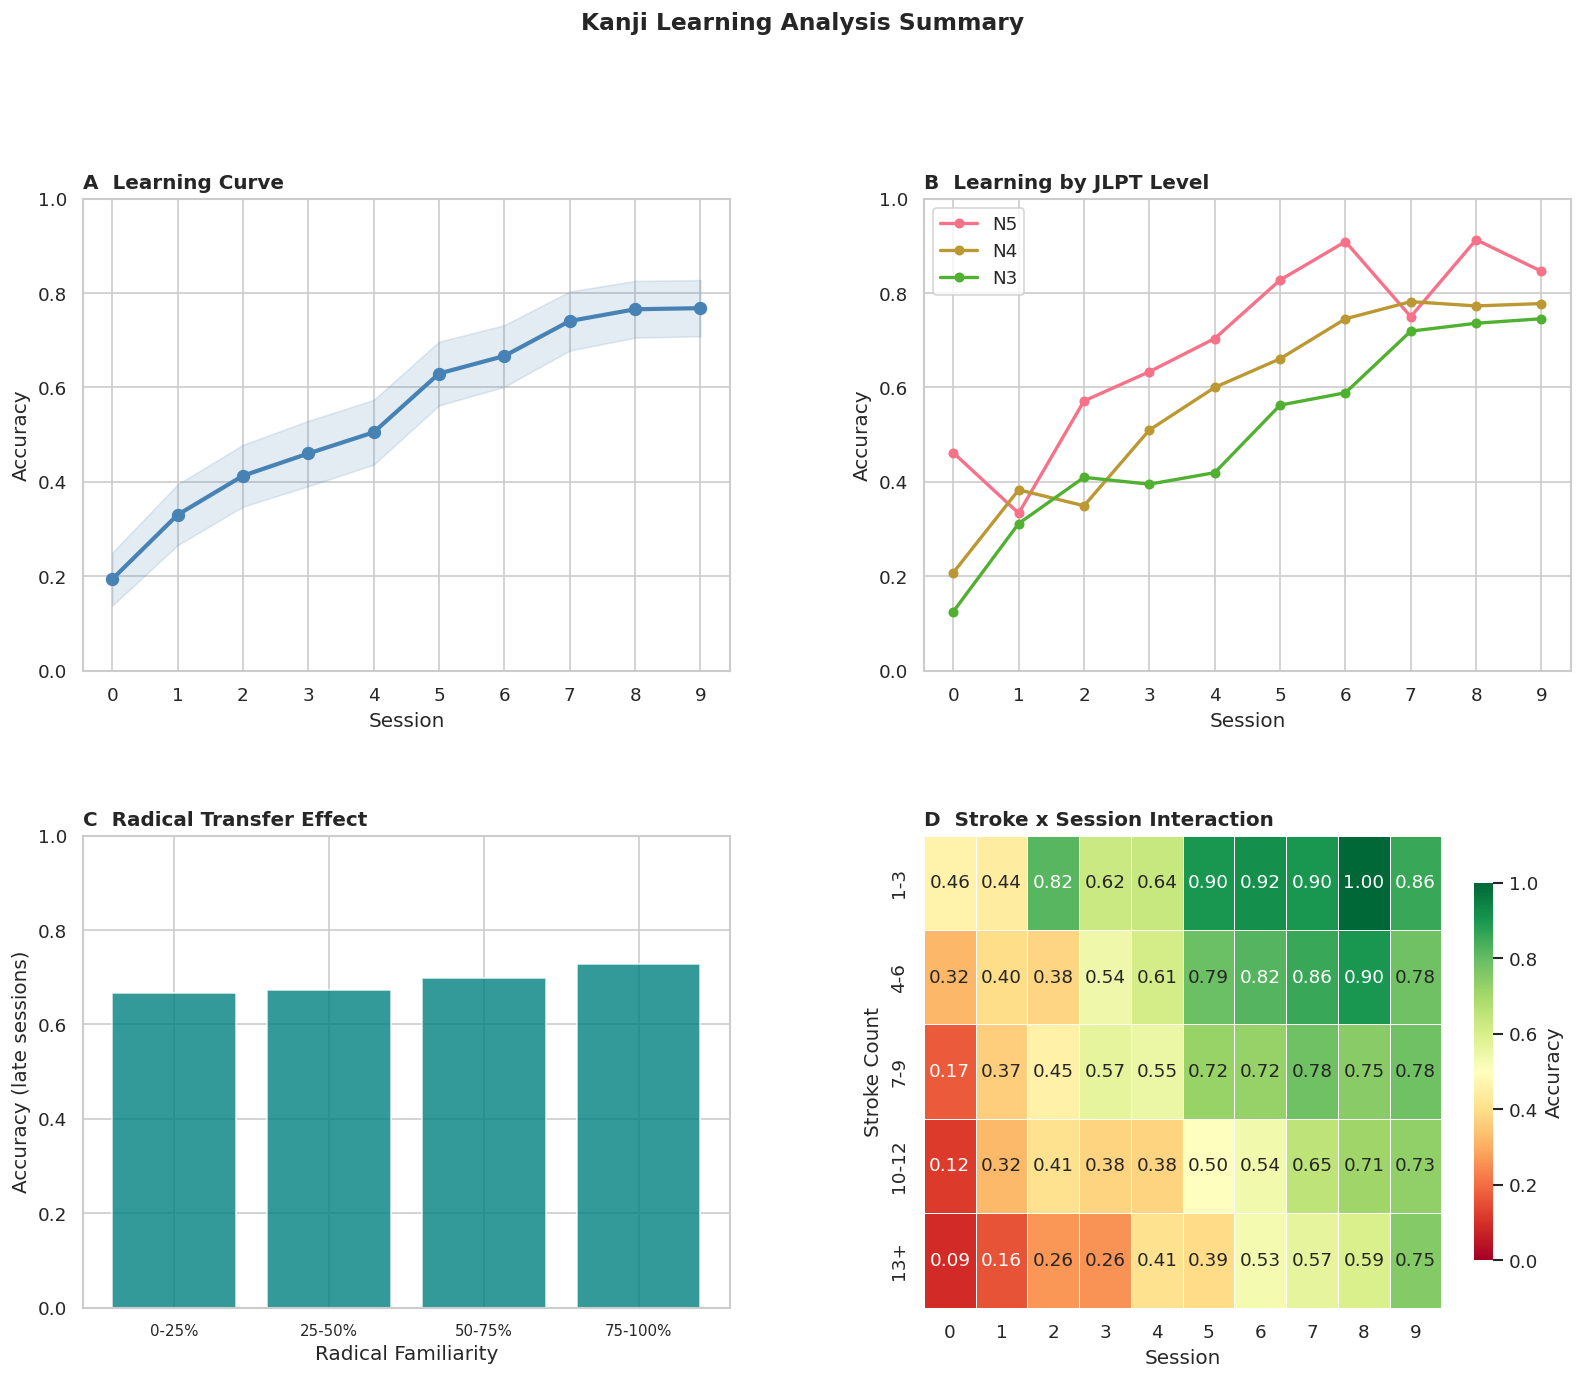

In [25]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.30)

# A: Overall learning curve
ax_a = fig.add_subplot(gs[0, 0])
ax_a.plot(session_overall["session"], session_overall["accuracy"],
          "o-", color="steelblue", lw=2.5, ms=7)
ax_a.fill_between(session_overall["session"],
                  session_overall["accuracy"] - 1.96 * session_overall["se_acc"],
                  session_overall["accuracy"] + 1.96 * session_overall["se_acc"],
                  color="steelblue", alpha=0.15)
ax_a.set_xlabel("Session")
ax_a.set_ylabel("Accuracy")
ax_a.set_title("A  Learning Curve", fontweight="bold", loc="left")
ax_a.set_ylim(0, 1)
ax_a.set_xticks(range(10))

# B: Accuracy by JLPT level over sessions
ax_b = fig.add_subplot(gs[0, 1])
for level in practice_levels:
    sub = df[df["jlpt_level"] == level].groupby("session")["correct_int"].mean().reset_index()
    ax_b.plot(sub["session"], sub["correct_int"], "o-", lw=2, ms=5, label=level)
ax_b.set_xlabel("Session")
ax_b.set_ylabel("Accuracy")
ax_b.set_title("B  Learning by JLPT Level", fontweight="bold", loc="left")
ax_b.legend()
ax_b.set_ylim(0, 1)
ax_b.set_xticks(range(10))

# C: Radical transfer effect
ax_c = fig.add_subplot(gs[1, 0])
ax_c.bar(range(len(fam_acc)), fam_acc.values, color="teal", alpha=0.8, edgecolor="white")
ax_c.set_xticks(range(len(fam_acc)))
ax_c.set_xticklabels(fam_acc.index, fontsize=9)
ax_c.set_xlabel("Radical Familiarity")
ax_c.set_ylabel("Accuracy (late sessions)")
ax_c.set_title("C  Radical Transfer Effect", fontweight="bold", loc="left")
ax_c.set_ylim(0, 1)

# D: Stroke x Session heatmap
ax_d = fig.add_subplot(gs[1, 1])
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Accuracy", "shrink": 0.8}, ax=ax_d)
ax_d.set_xlabel("Session")
ax_d.set_ylabel("Stroke Count")
ax_d.set_title("D  Stroke x Session Interaction", fontweight="bold", loc="left")

plt.suptitle("Kanji Learning Analysis Summary", fontweight="bold", fontsize=14, y=1.01)
plt.show()

## Summary

This notebook demonstrated how KanKyouKen's ResourceHub enables rich kanji
learning analysis by combining three reference datasets with practice event data.

### Key Findings (from synthetic data)

1. **Stroke count matters**: Higher stroke counts predict lower accuracy and
   slower response times, but this gap narrows with practice.

2. **JLPT level tracks difficulty**: N5 kanji are learned fastest; N3 kanji
   require more sessions to reach the same accuracy.

3. **Radical transfer is real**: Kanji whose radical components were already
   familiar from earlier practice show higher accuracy and faster RTs. This
   suggests curriculum ordering by shared radicals could accelerate learning.

4. **Individual differences persist**: Some participants show steep improvement
   curves while others start high but plateau.

### Applying This to Real Data

Replace the synthetic event generation (Section 3) with real practice events
from the KanKyouKen platform:

```python
from kankyouken import KanKyouKenClient

client = KanKyouKenClient(url="...", token="...")
events_df = pd.DataFrame([
    e.to_dict()
    for e in client.iter_events(study_id="...", event_type="kanji_practice")
])
```

The ResourceHub enrichment and all analyses in Sections 4--7 work unchanged.